In [1]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install -q pyspark findspark

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# No need to download Spark—pip installation includes Spark JARs

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ColabSpark").getOrCreate()
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# =========================================
# 4. Data Transformation (PySpark version, with CSV output)
# =========================================

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder

# -----------------------------
# Paths
# -----------------------------
base_dir = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs"
IN  = f"{base_dir}/final_constructed_table.parquet"
OUT_PARQUET = f"{base_dir}/final_transformed_table.parquet"
OUT_CSV     = f"{base_dir}/final_transformed_table.csv"
SUM = f"{base_dir}/transformation_summary.csv"
FIG = f"{base_dir}/fig_4_1_corr_distribution.png"

os.makedirs(base_dir, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df0 = spark.read.parquet(IN)
print(f"[Load] Rows: {df0.count()} | Columns: {len(df0.columns)}")

RID_COL, TARGET_COL = "RID", "AMIGR"

# -----------------------------
# Identify categorical vs continuous
# -----------------------------
known_continuous = {"AGE_P","BMI","ASISLEEP","ASIREST","BEDDAYR", "AHCNOYR2", "AHERNOY2","ASISLPFL" ,"YRSWRKPA" ,"ASISLPMD","ASISLPST","PAIN_INDEX","MENTAL_HEALTH_SCORE"}

int_coded_cats = set(df0.columns) - known_continuous - {"RID", "AMIGR"}

cat_cols = list(int_coded_cats)
cont_cols = list(known_continuous)
print(f"[Schema] Continuous = {len(cont_cols)} | Categorical = {len(cat_cols)}")

df = df0

[Load] Rows: 25403 | Columns: 85
[Schema] Continuous = 13 | Categorical = 70


In [14]:
# -----------------------------
# Horizontal reduction: low variance
# -----------------------------
dropped_low_var = []
row_count = df.count()
for c in cont_cols.copy():
    top_prop = df.groupBy(c).count().agg(F.max("count") / F.lit(row_count)).first()[0]
    if top_prop >= 0.95:
        dropped_low_var.append(c)
        cont_cols.remove(c)
        df = df.drop(c)

if dropped_low_var:
    print("[Reduce] Dropping near-constant:", dropped_low_var)

# -----------------------------
# Correlation-based removal
# -----------------------------
to_drop = set()
if len(cont_cols) > 1:
    corr_values = []
    for i, ci in enumerate(cont_cols):
        for cj in cont_cols[i+1:]:
            r = df.stat.corr(ci, cj)
            corr_values.append((ci, cj, r))
            if abs(r) >= 0.85:
                drop = cj if ci in known_continuous else ci
                to_drop.add(drop)

    corr_pdf = pd.DataFrame(corr_values, columns=["Var1","Var2","r"])
    plt.figure(figsize=(8,6))
    plt.hist(np.abs(corr_pdf["r"].dropna()), bins=30)
    plt.title("Figure 4.1: |Correlation| Distribution")
    plt.xlabel("|r|")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIG, dpi=200)
    plt.close()

if to_drop:
    print("[Reduce] Dropping high-correlation:", sorted(to_drop))
    df = df.drop(*list(to_drop))
    cont_cols = [c for c in cont_cols if c not in to_drop]

# -----------------------------
# Log transform skewed
# -----------------------------
log_cols = []
for c in cont_cols:
    stats = df.select(F.min(c).alias("minv"), F.skewness(c).alias("skew")).first()
    if stats.minv is not None and stats.minv >= 0 and abs(stats.skew) > 1:
        df = df.withColumn(c, F.log1p(F.col(c)))
        log_cols.append(c)

if log_cols:
    print("[Transform] log1p applied:", log_cols)

# -----------------------------
# Z-score standardization
# -----------------------------
assembler = VectorAssembler(inputCols=cont_cols, outputCol="cont_vec")
scaler = StandardScaler(inputCol="cont_vec", outputCol="cont_scaled", withMean=True, withStd=True)
scaled_df = scaler.fit(assembler.transform(df)).transform(assembler.transform(df))

# convert scaled vector to array, then extract each element safely
scaled_df = scaled_df.withColumn("cont_array", F.udf(lambda v: v.toArray().tolist(), "array<double>")(F.col("cont_scaled")))

for i, c in enumerate(cont_cols):
    scaled_df = scaled_df.withColumn(c, F.col("cont_array")[i])

df = scaled_df.drop("cont_vec", "cont_scaled", "cont_array")

df = scaled_df.drop("cont_vec", "cont_scaled")
z_cols = cont_cols
print(f"[Transform] z-scored {len(z_cols)} columns")

[Transform] log1p applied: ['BEDDAYR', 'ASISLPMD', 'AHERNOY2', 'ASISLPST', 'MENTAL_HEALTH_SCORE', 'ASISLPFL', 'PAIN_INDEX']
[Transform] z-scored 13 columns


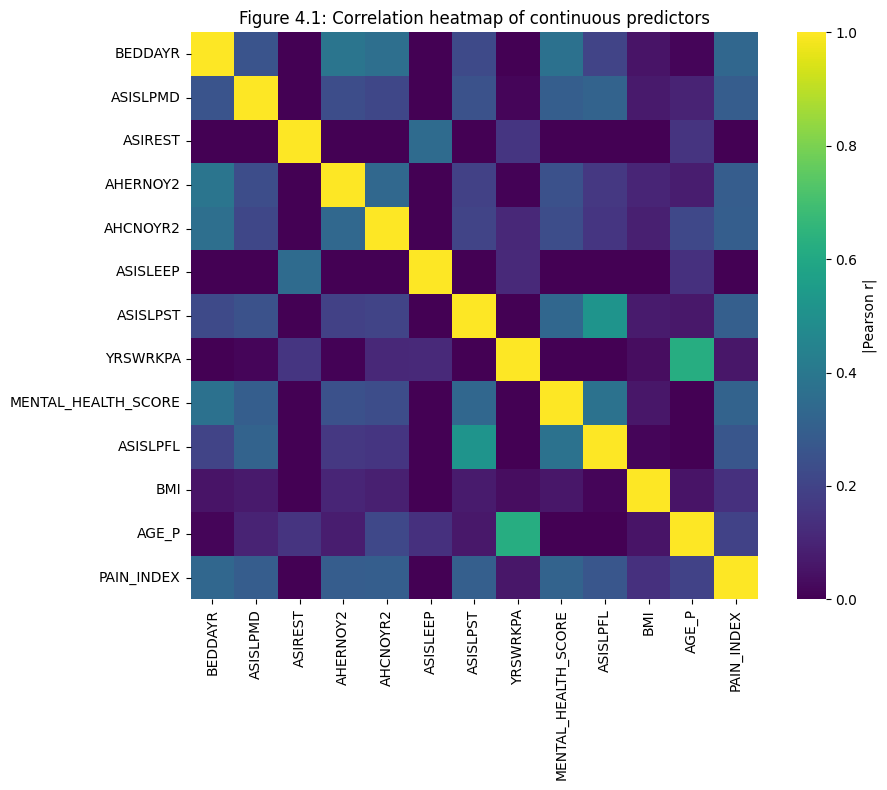

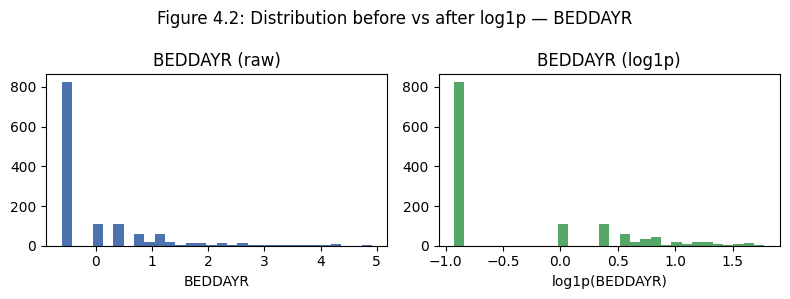

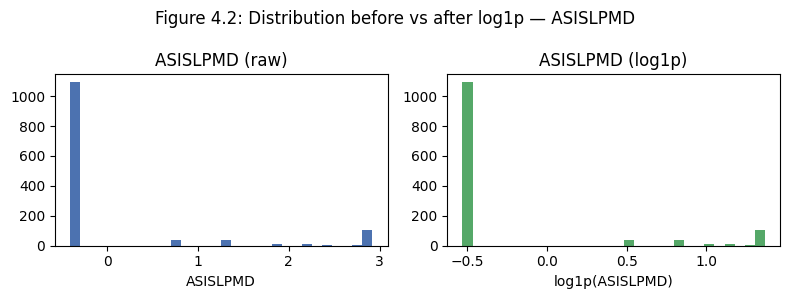

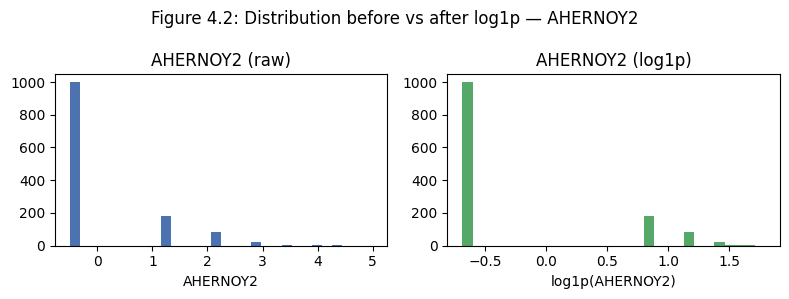

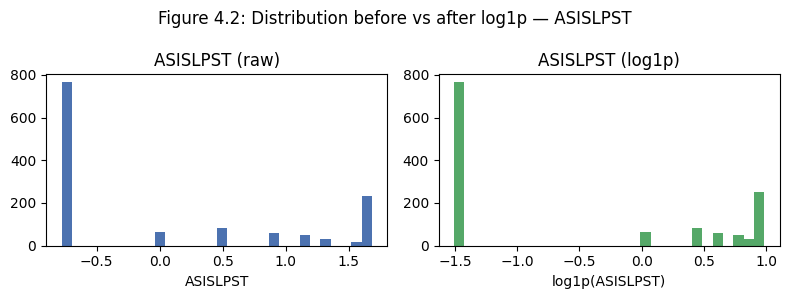

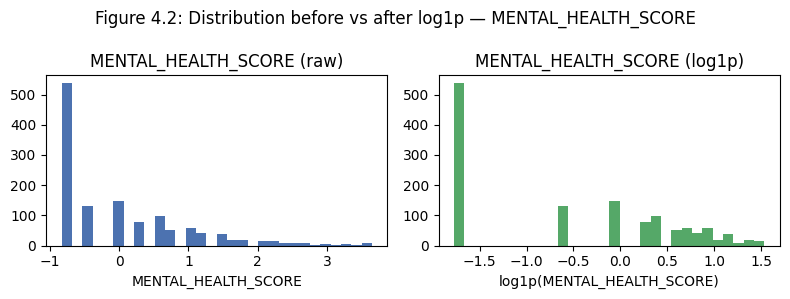

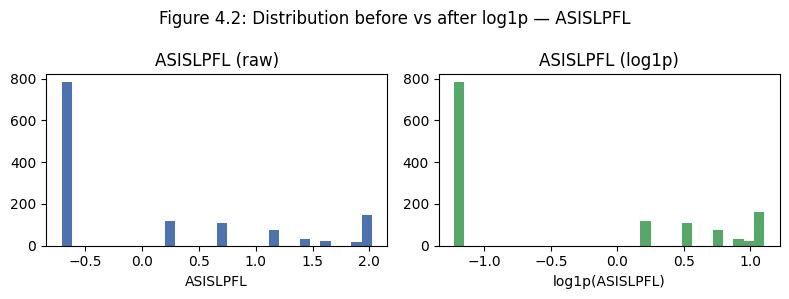

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


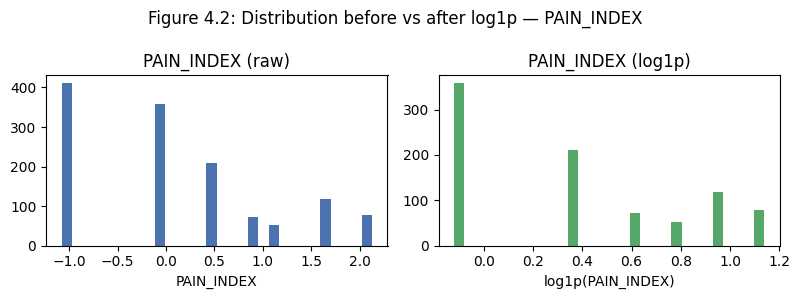

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

pdf_sample = df.select(cont_cols).sample(fraction=0.05, seed=42).toPandas()

# ---- Figure 4.1: Correlation heatmap of continuous predictors ----
if len(cont_cols) > 1:
    corr = pdf_sample[cont_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="viridis", vmin=0, vmax=1, square=True,
                annot=False, cbar_kws={'label': '|Pearson r|'})
    plt.title("Figure 4.1: Correlation heatmap of continuous predictors")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{base_dir}/fig_4_1_corr_heatmap.png", dpi=200)
    plt.close()

# ---- Figure 4.2: Log transform before vs after ----
for c in log_cols:
    if c in pdf_sample.columns:
        s_raw = pdf_sample[c].copy()
        s_log = np.log1p(s_raw)
        plt.figure(figsize=(8, 3))
        plt.subplot(1, 2, 1)
        plt.hist(s_raw.dropna(), bins=30, color="#4C72B0")
        plt.title(f"{c} (raw)")
        plt.xlabel(c)
        plt.subplot(1, 2, 2)
        plt.hist(s_log.dropna(), bins=30, color="#55A868")
        plt.title(f"{c} (log1p)")
        plt.xlabel(f"log1p({c})")
        plt.suptitle(f"Figure 4.2: Distribution before vs after log1p — {c}")
        plt.tight_layout()
        plt.show()
        plt.savefig(f"{base_dir}/fig_4_2_{c.lower()}_log.png", dpi=200)
        plt.close()

In [15]:
# -----------------------------
# One-hot encode categoricals (batch mode, safer)
# -----------------------------
from pyspark.ml import Pipeline

# 1. Build all StringIndexers and Encoders
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in cat_cols
]
encoders = [
    OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"])
    for c in cat_cols
]

# 2. Combine into a pipeline
pipeline = Pipeline(stages=indexers + encoders)

# 3. Fit and transform once
df = pipeline.fit(df).transform(df)

# 4. Drop original categorical and index columns
drop_cols = cat_cols + [f"{c}_idx" for c in cat_cols]
df = df.drop(*drop_cols)

print(f"[Encode] One-hot encoded {len(cat_cols)} columns (batch mode)")


[Encode] One-hot encoded 70 columns (batch mode)


In [17]:
# -----------------------------
# Save outputs (Parquet + CSV)
# -----------------------------
# 1️⃣ Always save full data as Parquet (supports vector)
df.write.mode("overwrite").parquet(OUT_PARQUET)

# 2️⃣ For CSV, only include non-complex columns
basic_cols = [c for c, t in df.dtypes if "vector" not in t and "array" not in t and "struct" not in t]
df_basic = df.select(basic_cols)

df_basic.write.mode("overwrite").option("header", True).csv(OUT_CSV)

summary = {
    "dropped_low_variance": dropped_low_var,
    "log_transformed": log_cols,
    "standardized": z_cols,
    "one_hot_columns": cat_cols
}
spark.createDataFrame([(k, json.dumps(v)) for k,v in summary.items()],
                      ["item","value_json"]).toPandas().to_csv(SUM, index=False)

print(f"\n[OK] Saved full table -> {OUT_PARQUET}")
print(f"[OK] Saved simplified CSV (non-vector) -> {OUT_CSV}")
print(f"[OK] Saved transformation summary -> {SUM}")
print(f"[OK] Saved correlation figure -> {FIG}")


[OK] Saved full table -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_transformed_table.parquet
[OK] Saved simplified CSV (non-vector) -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_transformed_table.csv
[OK] Saved transformation summary -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/transformation_summary.csv
[OK] Saved correlation figure -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/fig_4_1_corr_distribution.png


In [38]:
# =========================================
# 5. Feature Selection (Improved PySpark version)
# =========================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F
from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# Paths
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs"
FIG_PATH  = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs/figs"

os.makedirs(BASE_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

IN_PARQUET  = f"{BASE_PATH}/final_transformed_table.parquet"
OUT_PARQUET = f"{BASE_PATH}/final_selected_table.parquet"
OUT_JSON    = f"{BASE_PATH}/selected_features.json"

FIG_MI  = f"{FIG_PATH}/fig_4_3_mi_top20.png"
FIG_L1  = f"{FIG_PATH}/fig_4_4_l1_top20.png"

# -----------------------------
# 0) Load data
# -----------------------------
df = spark.read.parquet(IN_PARQUET)
print(f"[Load] Rows: {df.count()} | Columns: {len(df.columns)}")

RID_COL, TARGET_COL = "RID", "AMIGR"

# -----------------------------
# 1) Binary label encoding
# -----------------------------
df = df.withColumn("AMIGR_BIN", F.when(F.col("AMIGR") == 2, 1).otherwise(0))
TARGET_COL = "AMIGR_BIN"

# -----------------------------
# 2) Assemble feature vector
# -----------------------------
input_cols = [c for c in df.columns if c not in [RID_COL, "AMIGR", TARGET_COL]]
assembler = VectorAssembler(inputCols=input_cols, outputCol="features")
df_vec = assembler.transform(df).select(RID_COL, TARGET_COL, "features")

print(f"[Assemble] Using {len(input_cols)} predictors")

# =====================================================
# 3. Mutual Information (computed via sklearn sample)
# =====================================================

from pyspark.ml.functions import vector_to_array

# Expand vector columns if any (so sklearn can handle them)
vector_cols = [c for c, t in df.dtypes if "vector" in t and c != TARGET_COL]

if vector_cols:
    for vcol in vector_cols:
        df = df.withColumn(vcol + "_arr", vector_to_array(F.col(vcol)))
        size = df.select(F.size(F.col(vcol + "_arr")).alias("n")).first()["n"]
        for i in range(size):
            df = df.withColumn(f"{vcol}_{i}", F.col(vcol + "_arr")[i])
        df = df.drop(vcol, vcol + "_arr")
    print(f"[Expand] Expanded {len(vector_cols)} vector columns into numeric columns.")


[Load] Rows: 25403 | Columns: 85
[Assemble] Using 83 predictors
[Expand] Expanded 70 vector columns into numeric columns.
[Sample] MI sample shape: (5139, 814)


ValueError: y should be a 1d array, got an array of shape (5139, 2) instead.

[Sample] MI sample shape: (5139, 813)
[FS] MI-based selection kept 30 features


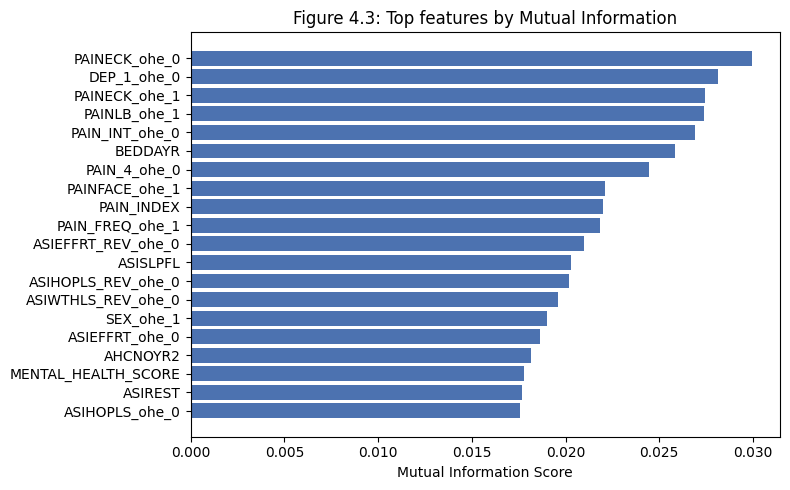

In [40]:
# Filter only numeric columns for sklearn (exclude target variables)
def is_label_col(c):
    return c.startswith("AMIGR") or c.endswith("_BIN") or "_AMIGR" in c

numeric_cols = [
    c for c, t in df.dtypes
    if t in ("double", "int", "float") and not is_label_col(c)
]

# Sample a subset to Pandas
sample_pdf = df.select(numeric_cols + [TARGET_COL]).sample(fraction=0.2, seed=42).toPandas()

# X = features only (no target)
X_sample = sample_pdf.drop(columns=[TARGET_COL]).fillna(0)

# y = single numeric label column
if isinstance(sample_pdf[TARGET_COL], pd.DataFrame):
    y_sample = sample_pdf[TARGET_COL].iloc[:, 0].astype(int)
else:
    y_sample = sample_pdf[TARGET_COL].astype(int)

print(f"[Sample] MI sample shape: {X_sample.shape}")

# --- Mutual Information (sklearn) ---
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_sample, y_sample, discrete_features='auto', random_state=42)
mi_df = pd.DataFrame({"Feature": X_sample.columns, "MI_Score": mi_scores})
mi_df = mi_df.sort_values("MI_Score", ascending=False)
top_mi_features = mi_df["Feature"].head(30).tolist()

print(f"[FS] MI-based selection kept {len(top_mi_features)} features")

# --- Figure 4.3: MI Top 20 ---
plt.figure(figsize=(8,5))
plt.barh(mi_df["Feature"].head(20)[::-1], mi_df["MI_Score"].head(20)[::-1], color="#4C72B0")
plt.title("Figure 4.3: Top features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.savefig(FIG_MI, dpi=200)
plt.show()
plt.close()

[Precheck] L1 usable features: 13 (removed 70 label/invalid cols)
[FS] L1 kept 13 features
                Feature   AbsCoef
12           PAIN_INDEX  0.461422
0                 AGE_P  0.449975
11  MENTAL_HEALTH_SCORE  0.240024
8               BEDDAYR  0.198554
3               ASIREST  0.163250
10             YRSWRKPA  0.124046
5              ASISLPFL  0.115624
1              AHCNOYR2  0.115076
6              ASISLPMD  0.049283
4              ASISLEEP  0.046525


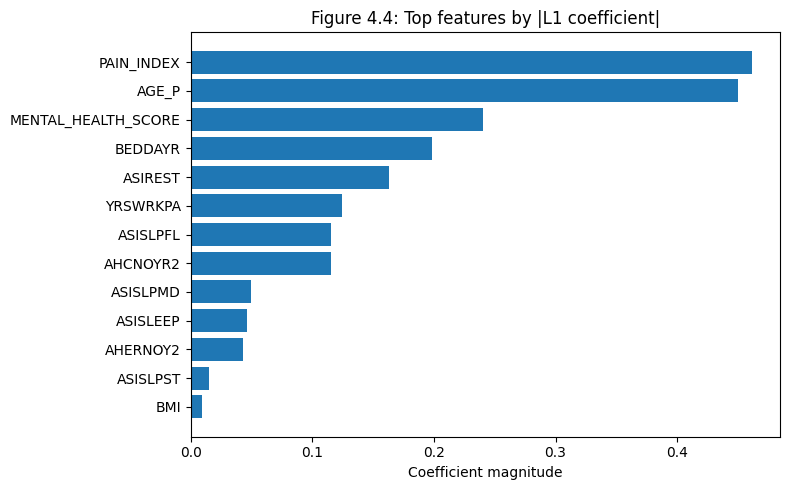

In [45]:
# =====================================================
# 4) L1 Logistic Regression (robust & leak-safe)
# =====================================================
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# --- 0. helpers ---
def is_label_col(c: str) -> bool:

    return bool(re.search(r"(?:^|_)AMIGR(?:_|$)", c)) or bool(re.search(r"(?:^|_)AMIGR_BIN(?:_|$)", c))


df_cols_set = set(df.columns)
filtered_input_cols = [c for c in input_cols if (c in df_cols_set) and (not is_label_col(c))]

if len(filtered_input_cols) == 0:
    raise ValueError("[L1] No usable feature columns after filtering. "
                     "Check input_cols and make sure they don't include label columns or non-existent columns.")

print(f"[Precheck] L1 usable features: {len(filtered_input_cols)} "
      f"(removed {len(input_cols) - len(filtered_input_cols)} label/invalid cols)")

# --- 2. assemble features ---
assembler_l1 = VectorAssembler(inputCols=filtered_input_cols, outputCol="features_l1")
df_l1 = assembler_l1.transform(df.select(filtered_input_cols + [TARGET_COL, RID_COL]))


df_l1 = df_l1.withColumn(TARGET_COL, F.col(TARGET_COL).cast("int"))

lr = LogisticRegression(
    featuresCol="features_l1",
    labelCol=TARGET_COL,
    family="binomial",      
    elasticNetParam=0.8,    
    regParam=0.001,         
    maxIter=300,
    standardization=True
)

lr_model = lr.fit(df_l1.cache())

# --- 4. extract coefficients 
try:
    coef = np.abs(lr_model.coefficients.toArray())             # binomial 
except Exception:
    coef = np.mean(np.abs(lr_model.coefficientMatrix.toArray()), axis=0)  # multinomial 


if len(coef) != len(filtered_input_cols):
    raise RuntimeError(f"[L1] Coef length mismatch: coef={len(coef)} vs features={len(filtered_input_cols)}. "
                       "Make sure you are using 'features_l1' from this block (not an earlier 'features').")

coef_df = pd.DataFrame({"Feature": filtered_input_cols, "AbsCoef": coef})
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

l1_features = coef_df.loc[coef_df["AbsCoef"] > 1e-6, "Feature"].tolist()

if len(l1_features) == 0:
    print("[L1] All coefficients ~ 0; relaxing regularization and refitting (regParam=0.0005)...")
    lr2 = lr.copy({lr.regParam: 0.0005})
    lr_model = lr2.fit(df_l1)
    try:
        coef = np.abs(lr_model.coefficients.toArray())
    except Exception:
        coef = np.mean(np.abs(lr_model.coefficientMatrix.toArray()), axis=0)
    coef_df = pd.DataFrame({"Feature": filtered_input_cols, "AbsCoef": coef}).sort_values("AbsCoef", ascending=False)
    l1_features = coef_df.loc[coef_df["AbsCoef"] > 1e-6, "Feature"].tolist()

print(f"[FS] L1 kept {len(l1_features)} features")
print(coef_df.head(10))

# --- 5. plot Figure 4.4  ---
plt.figure(figsize=(8,5))
top20 = coef_df.head(20)
plt.barh(top20["Feature"][::-1], top20["AbsCoef"][::-1])
plt.title("Figure 4.4: Top features by |L1 coefficient|")
plt.xlabel("Coefficient magnitude")
plt.tight_layout()
plt.savefig(FIG_L1, dpi=200)
plt.show()
plt.close()

In [46]:
# =====================================================
# 5. Union of MI and L1 (Iteration 3 logic)
# =====================================================
selected_union = sorted(list(set(top_mi_features) | set(l1_features)))
print(f"[FS] Final union: {len(selected_union)} features")

# Save union features for next modeling step
selected_df = df.select([RID_COL, "AMIGR", TARGET_COL] + selected_union)
selected_df.write.mode("overwrite").parquet(OUT_PARQUET)

summary_dict = {
    "MI_top": top_mi_features,
    "L1_top": l1_features,
    "Union": selected_union
}
with open(OUT_JSON, "w") as f:
    json.dump(summary_dict, f, indent=2)

print(f"[OK] Saved final selected table -> {OUT_PARQUET}")
print(f"[OK] Saved feature lists -> {OUT_JSON}")

[FS] Final union: 36 features
[OK] Saved final selected table -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_selected_table.parquet
[OK] Saved feature lists -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/selected_features.json



[FS] Feature overlap summary:
 - MI-like only: 23
 - L1 only: 6
 - Overlap: 7 / 36 (19.4%)


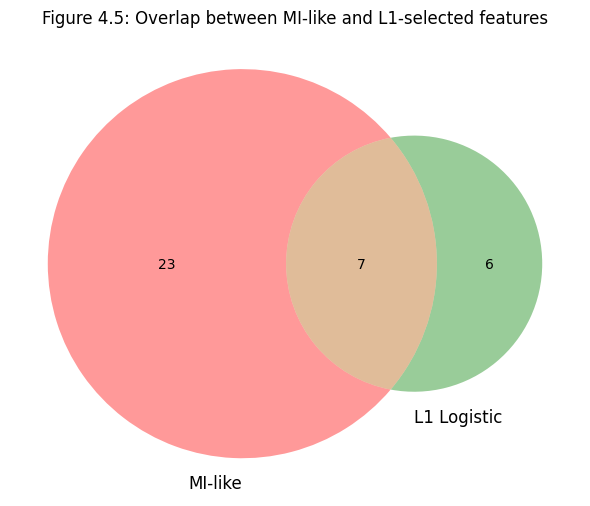

[OK] Saved overlap figure -> /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/figs/fig_4_5_feature_overlap.png


In [47]:
# =========================================
# 6) Visualization: Overlap of MI-like and L1-selected features
# =========================================
from matplotlib_venn import venn2

# Compute overlap
mi_set = set(top_mi_features)
l1_set = set(l1_features)
union_set = mi_set | l1_set
intersect_set = mi_set & l1_set

print("\n[FS] Feature overlap summary:")
print(f" - MI-like only: {len(mi_set - l1_set)}")
print(f" - L1 only: {len(l1_set - mi_set)}")
print(f" - Overlap: {len(intersect_set)} / {len(union_set)} ({len(intersect_set)/len(union_set)*100:.1f}%)")

# Plot Venn diagram
plt.figure(figsize=(6,6))
venn2(
    subsets=(len(mi_set - l1_set), len(l1_set - mi_set), len(intersect_set)),
    set_labels=('MI-like', 'L1 Logistic')
)
plt.title("Figure 4.5: Overlap between MI-like and L1-selected features")
plt.tight_layout()
plt.show()
plt.savefig(f"{FIG_PATH}/fig_4_5_feature_overlap.png", dpi=200)
plt.close()

print(f"[OK] Saved overlap figure -> {FIG_PATH}/fig_4_5_feature_overlap.png")